# Convolutional neural networks

## What is a convolution?

A **convolution** combines a signal (or image) with a small **kernel** (also called a *filter*) by sliding the kernel across the data and computing a weighted sum at each position.

For images, the kernel extracts local features such as

- edges,
- corners,
- textures, or
- simple patterns.

Since the **same kernel is applied everywhere**, a convolutional neural network can recognize the same feature regardless of where it appears in the image. During training, the network automatically learns kernels that are useful for the prediction task.


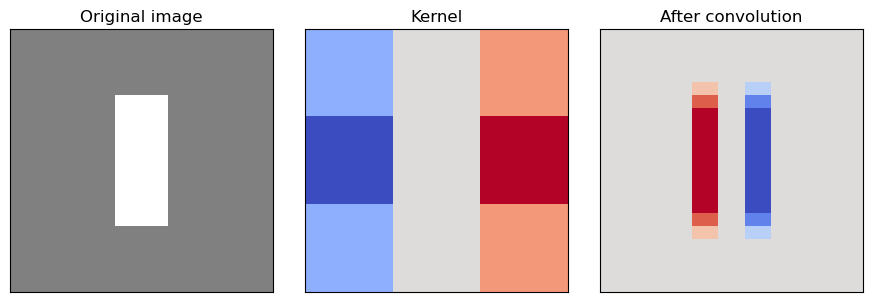

In [2]:
import numpy as np
import matplotlib.pyplot as plt
#from scipy.ndimage import convolve
from scipy.ndimage import correlate

# Simple toy image
image = np.zeros((20, 20))
image[5:15, 8:12] = 1

# Vertical edge detector (Sobel-x filter)
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Most CNNs actually implement cross-correlation,
# which is simply applying the kernel to the points
# further ahead in the sum, instead of the points behind
# it (i-m,j-n in eq. (1)).

#filtered = convolve(image, kernel)
filtered = correlate(image, kernel)

fig, ax = plt.subplots(1, 3, figsize=(9, 3))

ax[0].imshow(image, cmap="gray", vmin=-1, vmax=1)
ax[0].set_title("Original image")

ax[1].imshow(kernel, cmap="coolwarm")
ax[1].set_title("Kernel")

ax[2].imshow(filtered, cmap="coolwarm")
ax[2].set_title("After convolution")

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.tight_layout()
plt.show()


As can be seen now, after applying the kernel the convoluted (or rather cross-correlated) image shows a positive response for a dark->white vertical edge and a negative response for a white->dark vertical edge. In order to detect the horizontal edges the Sobel-y filter needs to be applied, which is simply the transpose of the Sobel-x filter applied here.

## From dense to convolutional layers

In the basic neural network notebook, every neuron in layer $L$ is connected to *all* neurons in layer $L-1$ through a weight matrix $\boldsymbol{W}^{(L)}$. For image data this is wasteful: nearby pixels are related, and a pattern (an edge, a corner) can appear anywhere in the image.

A convolutional layer instead applies a small, shared set of weights — a *kernel* (or *filter*) $\boldsymbol{K}$ — that slides over the input and produces a *feature map*. For a 2D input image $X$ and kernel $K$ of size $k \times k$, the output at position $(i,j)$ is

$$
(X * K)_{ij} = \sum_{m=0}^{k-1}\sum_{n=0}^{k-1} X_{i+m,\,j+n}\, K_{m,n}
$$

(1)

Because the same kernel is reused at every position, the number of parameters does not grow with image size, and the network becomes *translation invariant*: a learned feature (e.g. an edge detector) is recognized wherever it occurs in the image.

## Components and structure

A typical CNN architecture stacks the following building blocks.

| Layer type | Purpose |
| --- | --- |
| Convolution | Extracts local features (edges, textures) using shared kernels |
| Activation (e.g. ReLU) | Introduces nonlinearity |
| Pooling | Downsamples feature maps, adding translation tolerance |
| Fully connected (dense) | Combines extracted features into a final prediction |

Pooling (most commonly *max pooling*) reduces a $p \times p$ patch of a feature map to a single value,

$$
\mathrm{maxpool}(X)_{ij} = \max_{0 \le m,n < p} X_{ip+m,\,jp+n}
$$

(2)

which both shrinks the data and makes the representation more robust to small shifts in the input.

## Limited-resource implementation

Training a full CNN (with learned kernels) usually requires a deep learning framework such as PyTorch or TensorFlow and a GPU. With limited resources, a very effective and instructive alternative is to use a small set of **fixed, classical kernels** (edge detectors) to perform the convolution + pooling step by hand with `numpy`, and then feed the resulting feature maps into the `sklearn` multilayer perceptron (MLP) we already know from the basics notebook. This keeps the conceptual pipeline of a CNN (convolve → activate → pool → dense layers) while remaining trainable in seconds on a laptop.

## Library imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn


## Data preparation

We use the `digits` data set: 1797 grayscale images of handwritten digits (0-9), each $8 \times 8$ pixels.

Number of images: 1797
Image size       : (8, 8)


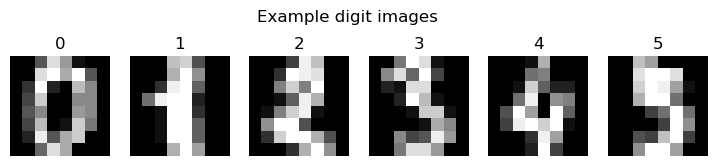

In [4]:
digits = sklearn.datasets.load_digits()

X_images = digits.images          # shape (n_samples, 8, 8)
y = digits.target

print("Number of images:", X_images.shape[0])
print("Image size       :", X_images.shape[1:])

fig, axes = plt.subplots(1, 6, figsize=(9, 2))
for ax, img, label in zip(axes, X_images[:6], y[:6]):
    ax.imshow(img, cmap="gray")
    ax.set_title(label)
    ax.axis("off")
plt.suptitle("Example digit images")
plt.show()


## The convolution step

We define two small $3\times3$ kernels that act as edge detectors (a horizontal and a vertical Sobel filter), apply Eq. (1) to every image and pass the result through a ReLU activation.

In [5]:
def convolve2d(img, kernel):
    k = kernel.shape[0]
    h, w = img.shape
    out = np.zeros((h - k + 1, w - k + 1))
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            patch = img[i:i + k, j:j + k]
            out[i, j] = np.sum(patch * kernel)
    return out

def relu(x):
    return np.maximum(0, x)

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = sobel_x.T

def extract_features(img):
    fmap_x = relu(convolve2d(img, sobel_x))
    fmap_y = relu(convolve2d(img, sobel_y))
    return np.concatenate([fmap_x.ravel(), fmap_y.ravel()])

X_features = np.array([extract_features(img) for img in X_images])
print("Feature vector length per image without maxpooling:", X_features.shape[1])


Feature vector length per image without maxpooling: 72


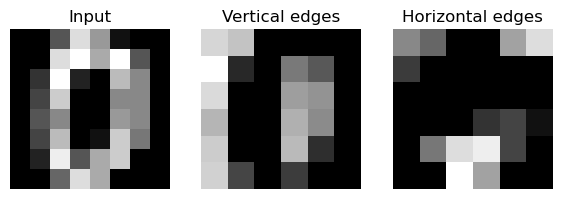

In [6]:
example = X_images[0]
fmap_x = relu(convolve2d(example, sobel_x))
fmap_y = relu(convolve2d(example, sobel_y))

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
axes[0].imshow(example, cmap="gray"); axes[0].set_title("Input")
axes[1].imshow(fmap_x, cmap="gray"); axes[1].set_title("Vertical edges")
axes[2].imshow(fmap_y, cmap="gray"); axes[2].set_title("Horizontal edges")
for ax in axes:
    ax.axis("off")
plt.show()


## The pooling step

On top of the convolution and the activation we then apply $2\times2$ max pooling, Eq. (2).

In [7]:
def maxpool2d(img, p=2):
    h, w = img.shape
    h_out, w_out = h // p, w // p
    out = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            out[i, j] = np.max(img[i * p:(i + 1) * p, j * p:(j + 1) * p])
    return out

def extract_features(img):
    fmap_x = maxpool2d(relu(convolve2d(img, sobel_x)))
    fmap_y = maxpool2d(relu(convolve2d(img, sobel_y)))
    return np.concatenate([fmap_x.ravel(), fmap_y.ravel()])

X_features = np.array([extract_features(img) for img in X_images])
print("Feature vector length per image with maxpooling:", X_features.shape[1])

Feature vector length per image with maxpooling: 18


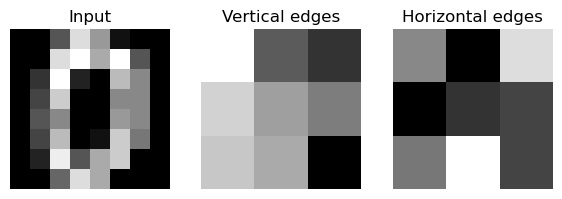

In [8]:
example = X_images[0]
fmap_x = maxpool2d(relu(convolve2d(example, sobel_x)))
fmap_y = maxpool2d(relu(convolve2d(example, sobel_y)))

fig, axes = plt.subplots(1, 3, figsize=(7, 2.5))
axes[0].imshow(example, cmap="gray"); axes[0].set_title("Input")
axes[1].imshow(fmap_x, cmap="gray"); axes[1].set_title("Vertical edges")
axes[2].imshow(fmap_y, cmap="gray"); axes[2].set_title("Horizontal edges")
for ax in axes:
    ax.axis("off")
plt.show()

## Split and scale data

In [9]:
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X_features,
    y,
    test_size=0.20,
    stratify=y,
)

scaler = sklearn.preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Dense (fully connected) classifier head

The pooled feature maps are flattened and fed into an `MLPClassifier`, exactly as in the basic neural network notebook. This plays the role of the fully connected layers at the end of a CNN.

In [10]:
mlp = sklearn.neural_network.MLPClassifier(
    hidden_layer_sizes=(32,),
    activation="relu",
    solver="adam",
    max_iter=500,
)

mlp.fit(X_train_scaled, y_train)


,hidden_layer_sizes,"(32,)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,500
,shuffle,True
,random_state,None


## Model evaluation

In [11]:
y_pred = mlp.predict(X_test_scaled)

print(sklearn.metrics.classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       1.00      0.94      0.97        36
           2       0.97      1.00      0.99        35
           3       0.97      0.92      0.94        37
           4       0.97      0.97      0.97        36
           5       0.95      0.95      0.95        37
           6       0.97      0.97      0.97        36
           7       1.00      0.97      0.99        36
           8       0.88      1.00      0.93        35
           9       0.94      0.94      0.94        36

    accuracy                           0.96       360
   macro avg       0.97      0.96      0.96       360
weighted avg       0.97      0.96      0.96       360



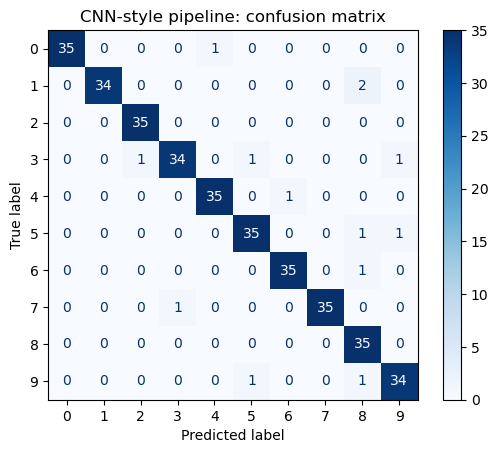

In [12]:
cm = sklearn.metrics.confusion_matrix(y_test, y_pred)
disp = sklearn.metrics.ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("CNN-style pipeline: confusion matrix")
plt.show()


## Remark

Using ReLu discards all of the negative responses and even with an other activation function, maxpooling would discard them in the pooling step. This is still done in practice rather than using e.g. tanh and an adapted pooling strategy, because they are much faster to compute. The lag of negative response information is in practice compensated for by using a second filter per dimension, which gives the same responses with opposite signs.

## Take-away

A real CNN *learns* the kernels (rather than using fixed Sobel filters) through backpropagation, and stacks many convolution/pooling blocks. The pipeline above — convolve, activate, pool, flatten, dense — is exactly the structure of a CNN, and reproducing it with fixed kernels and `sklearn` is a lightweight way to build intuition before moving to a full deep learning framework (e.g. PyTorch, `torch.nn.Conv2d`) for projects that need *learned* filters and larger image data sets.


### Bioengineering applications

Convolutional neural networks are widely used for image-based biological and medical data, for example microscopy images of cells, histopathology slides, fluorescence microscopy and radiological images. In this course we avoid additional deep-learning dependencies and instead use a NumPy/scikit-learn style implementation to illustrate the underlying computations. In practice, these models are almost always implemented using PyTorch or TensorFlow/Keras.

### Model selection

As for all supervised learning methods, hyperparameters (number of filters, kernel size, pooling strategy, learning rate and network depth) should be selected using a validation set or cross-validation rather than the test set. Typical scikit-learn tools are `train_test_split`, `cross_val_score`, `GridSearchCV` and `RandomizedSearchCV`.
